## Import

In [1]:
## IMPORT 

import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import glob
import seaborn as sns
from collections import defaultdict
from matplotlib.ticker import MaxNLocator
from sklearn.metrics import classification_report, confusion_matrix, precision_score, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from imblearn.under_sampling import RandomUnderSampler
from scipy.stats import ttest_ind
from tqdm import tqdm

## plotting params

In [2]:
# Text   
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.size'] = 20
mpl.rcParams['font.family'] = '.SF Camera'

# Boxes
mpl.rcParams['axes.spines.top']= False
mpl.rcParams['axes.spines.right']= False

# plt.rcParams['figure.figsize'] = [4, 5]
plt.rcParams['figure.dpi'] = 140

## data loading + sliding window function

In [3]:

#SAM
directory = '/Users/ossamaghenissa/Desktop/CMRlabproject/fiberphotometry/MG/SAM/preprocessedfulltracezscoreg/'
sam_files = glob.glob(os.path.join(directory, "*.csv"))

sam_files

#EPM 
directory = '/Users/ossamaghenissa/Desktop/CMRlabproject/fiberphotometry/MG/EPM/preprocessedfulltracezscoreg/'
epm_files = glob.glob(os.path.join(directory, "*.csv"))

epm_files

# SLIDING WINDOW FUNCTION
def create_sliding_window(df, signal_col, target_col, window_size, step_size=30):
    X, y = [], []
    for i in range(0, len(df) - window_size, step_size):
        window_signal = df[signal_col].iloc[i:i + window_size].values
        window_labels = df[target_col].iloc[i:i + window_size]
        if len(window_labels.unique()) == 1:  # Ensure all labels in the window are the same
            X.append(window_signal)
            y.append(window_labels.iloc[0])
    return np.array(X), np.array(y)

print(sam_files, epm_files)

['/Users/ossamaghenissa/Desktop/CMRlabproject/fiberphotometry/MG/SAM/preprocessedfulltracezscoreg/364_F_mCherry_preprocessed.csv', '/Users/ossamaghenissa/Desktop/CMRlabproject/fiberphotometry/MG/SAM/preprocessedfulltracezscoreg/363_F_mCherry_preprocessed.csv', '/Users/ossamaghenissa/Desktop/CMRlabproject/fiberphotometry/MG/SAM/preprocessedfulltracezscoreg/273_M_mCherry_preprocessed.csv', '/Users/ossamaghenissa/Desktop/CMRlabproject/fiberphotometry/MG/SAM/preprocessedfulltracezscoreg/224_M_kd_preprocessed.csv', '/Users/ossamaghenissa/Desktop/CMRlabproject/fiberphotometry/MG/SAM/preprocessedfulltracezscoreg/396_M_mCherry_preprocessed.csv', '/Users/ossamaghenissa/Desktop/CMRlabproject/fiberphotometry/MG/SAM/preprocessedfulltracezscoreg/238_F_kd_preprocessed.csv', '/Users/ossamaghenissa/Desktop/CMRlabproject/fiberphotometry/MG/SAM/preprocessedfulltracezscoreg/268_M_kd_preprocessed.csv', '/Users/ossamaghenissa/Desktop/CMRlabproject/fiberphotometry/MG/SAM/preprocessedfulltracezscoreg/243_F_m

### kd vs mcherry decoder

In [4]:
## dictionnary 
cm_dict = defaultdict(list)                
shuffled_cm_dict = defaultdict(list)

results = {
    'ID': [], 'condition': [],
    'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': [],
    '1_f1': [], '0_f1': [], 'AUC_ROC': [],
    'Shuffled_Accuracy': [], 'Shuffled_Precision': [],
    'Shuffled_Recall': [], 'Shuffled_F1': [],
    'Shuffled_1_f1': [], 'Shuffled_0_f1': [],
    'Shuffled_AUC_ROC': []
}

num_repeats = 20
num_permutations = 50
window_size = 300

## main decoder

for efile, sfile in zip(epm_files, sam_files):

    epm = pd.read_csv(efile)
    sam = pd.read_csv(sfile)

    mouse_id = epm['ID'].iloc[0]
    condition = sam['condition'].iloc[0]

    # Labels
    epm['exploration'] = np.where(epm['In Closed Arms'] == 1, 0, 1)
    sam['exploration'] = np.where(sam['In black'] == 1, 0, 1)

    epm = epm[['Zscoreg', 'Time', 'exploration', 'ID', 'condition']]
    sam = sam[['Zscoreg', 'Time', 'exploration', 'ID', 'condition']]

    X_train, y_train = create_sliding_window(
        sam, 'Zscoreg', 'exploration', window_size
    )
    X_test, y_test = create_sliding_window(
        epm, 'Zscoreg', 'exploration', window_size
    )

    best_pos_precision = -np.inf
    best_repeat_pred = None
    best_repeat_prob = None
    best_repeat_C = None
    best_repeat_solver = None

    for repeat_idx in tqdm(range(num_repeats), desc="Repeats"):

        ## undersampling 

        undersampler = RandomUnderSampler(
            random_state=repeat_idx, sampling_strategy=1
        )
        X_res, y_res = undersampler.fit_resample(X_train, y_train)

        ## LR model + grid search

        model = LogisticRegression(penalty='l2', class_weight='balanced', max_iter=5000, random_state=repeat_idx)

        grid = GridSearchCV(
            model, param_grid={
                'C': [0.0001, 0.001, 0.01, 0.1, 1],
                'solver': ['liblinear', 'lbfgs']
            },
            scoring='accuracy',
            cv=3,
            n_jobs=-1
        )

        grid.fit(X_res, y_res)
        best_model = grid.best_estimator_

        best_C = best_model.C
        best_solver = best_model.solver

        best_model.fit(X_res, y_res)

        # Predict on test set
        y_pred = best_model.predict(X_test)
        y_prob = best_model.predict_proba(X_test)[:, 1]

        ## rep work 

        # Compute precision for positive class
        prec_pos = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
        # prec_pos = recall_score(y_test, y_pred, pos_label=1, zero_division=0)

        # Track best repeat 
        if prec_pos > best_pos_precision:
            best_pos_precision = prec_pos
            best_repeat_pred = y_pred
            best_repeat_prob = y_prob
            best_repeat_C = best_C
            best_repeat_solver = best_solver

        # Store metrics & confusion matrices
        auc = roc_auc_score(y_test, y_prob)
        cm = confusion_matrix(y_test, y_pred, normalize='true')
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

        cm_dict[(condition, mouse_id)].append(cm)

        results['ID'].append(mouse_id)
        results['condition'].append(condition)
        results['Accuracy'].append(report['accuracy'])
        results['Precision'].append(report['weighted avg']['precision'])
        results['Recall'].append(report['weighted avg']['recall'])
        results['F1'].append(report['weighted avg']['f1-score'])
        results['1_f1'].append(report['1']['f1-score'])
        results['0_f1'].append(report['0']['f1-score'])
        results['AUC_ROC'].append(auc)

        # ---------- SHUFFLED ----------
        shuffled_cm_list = []
        shuffled_metrics = []

        for i in range(num_permutations):
            np.random.seed(repeat_idx + i)
            y_shuff = np.random.permutation(y_res)

            best_model.fit(X_res, y_shuff)
            y_pred_s = best_model.predict(X_test)
            y_prob_s = best_model.predict_proba(X_test)[:, 1]

            shuffled_cm_list.append(
                confusion_matrix(y_test, y_pred_s, normalize='true')
            )

            rep = classification_report(y_test, y_pred_s, output_dict=True, zero_division=0)
            shuffled_metrics.append({
                'Accuracy': rep['accuracy'],
                'Precision': rep['macro avg']['precision'],
                'Recall': rep['macro avg']['recall'],
                'F1': rep['macro avg']['f1-score'],
                '1_f1': rep['1']['f1-score'],
                '0_f1': rep['0']['f1-score'],
                'AUC': roc_auc_score(y_test, y_prob_s)
            })

        shuffled_cm_dict[(condition, mouse_id)].append(
            np.mean(shuffled_cm_list, axis=0)
        )

        avg_shuff = pd.DataFrame(shuffled_metrics).mean()

        results['Shuffled_Accuracy'].append(avg_shuff['Accuracy'])
        results['Shuffled_Precision'].append(avg_shuff['Precision'])
        results['Shuffled_Recall'].append(avg_shuff['Recall'])
        results['Shuffled_F1'].append(avg_shuff['F1'])
        results['Shuffled_1_f1'].append(avg_shuff['1_f1'])
        results['Shuffled_0_f1'].append(avg_shuff['0_f1'])
        results['Shuffled_AUC_ROC'].append(avg_shuff['AUC'])


### average confusion matrices
avg_cm_mouse = {k: np.mean(v, axis=0) for k, v in cm_dict.items()}
avg_shuff_cm_mouse = {k: np.mean(v, axis=0) for k, v in shuffled_cm_dict.items()}

cm_by_condition = defaultdict(list)
shuff_cm_by_condition = defaultdict(list)

for (cond, _), cm in avg_cm_mouse.items():
    cm_by_condition[cond].append(cm)
for (cond, _), cm in avg_shuff_cm_mouse.items():
    shuff_cm_by_condition[cond].append(cm)

final_cm = {cond: np.mean(v, axis=0) for cond, v in cm_by_condition.items()}
final_shuff_cm = {cond: np.mean(v, axis=0) for cond, v in shuff_cm_by_condition.items()}


## results df
results_df = pd.DataFrame(results)

group_keys = ['ID', 'condition']

numeric_cols = (
    results_df
    .select_dtypes(include='number')
    .columns
    .drop(group_keys, errors='ignore')
)

average_results = (
    results_df
    .groupby(group_keys)[numeric_cols]
    .mean()
    .reset_index()
)

print(average_results)




Repeats: 100%|██████████| 20/20 [00:07<00:00,  2.85it/s]

     ID condition  Accuracy  ...  Shuffled_1_f1  Shuffled_0_f1  Shuffled_AUC_ROC
0   223        kd  0.545751  ...       0.452269       0.498640          0.503553
1   224        kd  0.828406  ...       0.393626       0.597738          0.526839
2   238        kd  0.731479  ...       0.341847       0.622235          0.533990
3   239        kd  0.560127  ...       0.445985       0.532931          0.490868
4   243   mCherry  0.853016  ...       0.357932       0.574130          0.505684
5   249        kd  0.672747  ...       0.457433       0.520008          0.487729
6   261        kd  0.783375  ...       0.391219       0.560495          0.503510
7   268        kd  0.467254  ...       0.547470       0.425653          0.501385
8   269        kd  0.411544  ...       0.426474       0.555909          0.500250
9   273   mCherry  0.841899  ...       0.256415       0.582615          0.466287
10  277   mCherry  0.857551  ...       0.409163       0.548384          0.487883
11  352   mCherry  0.808183 

#### individual confusion matrices

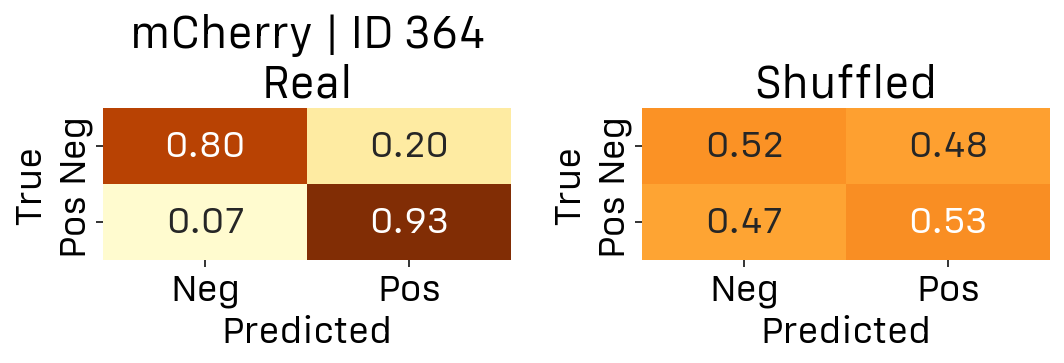

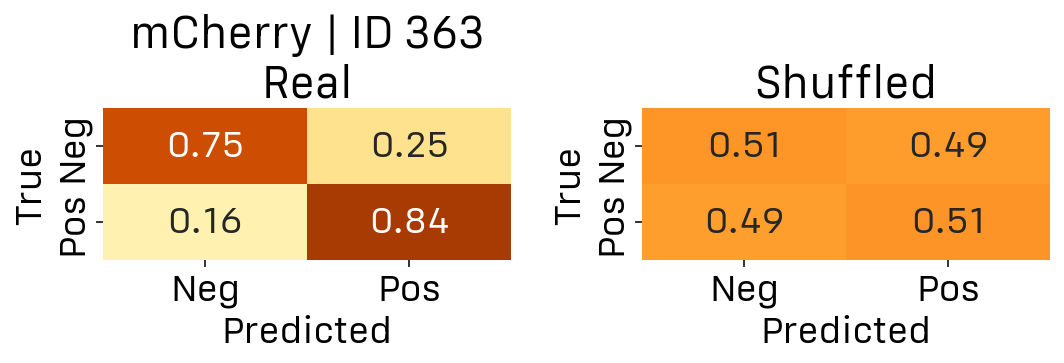

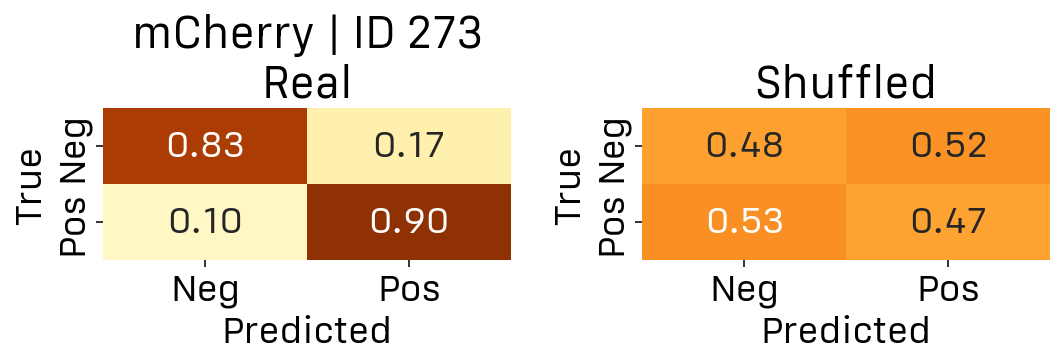

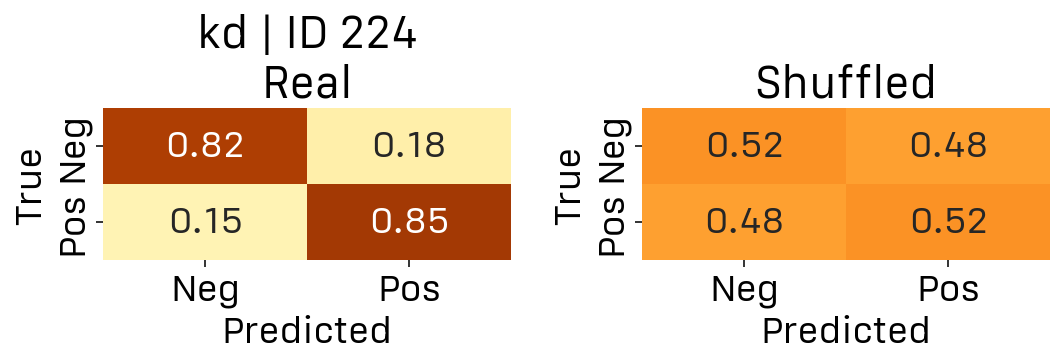

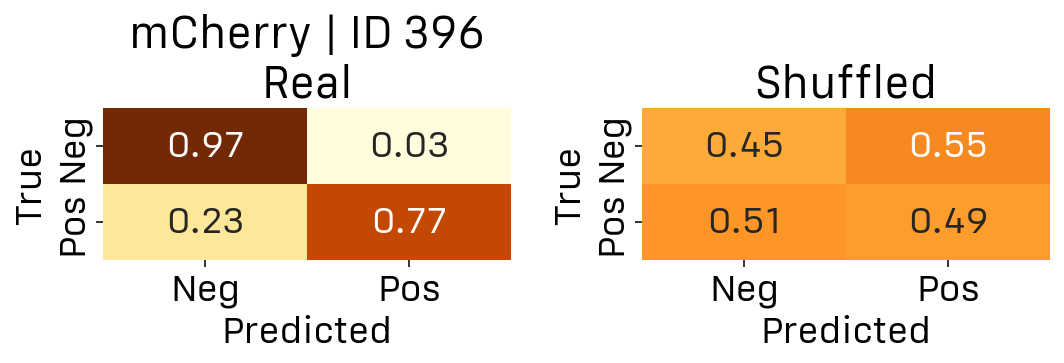

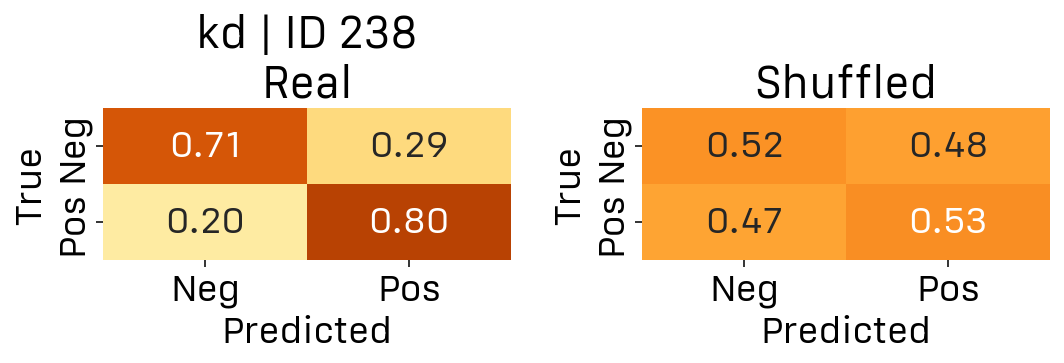

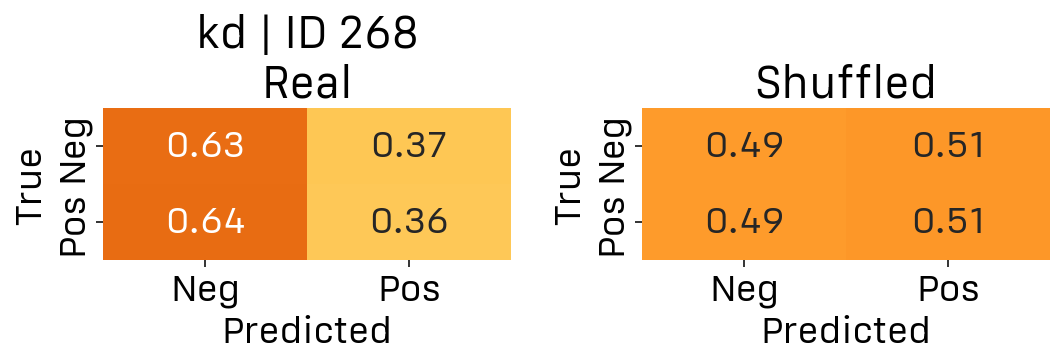

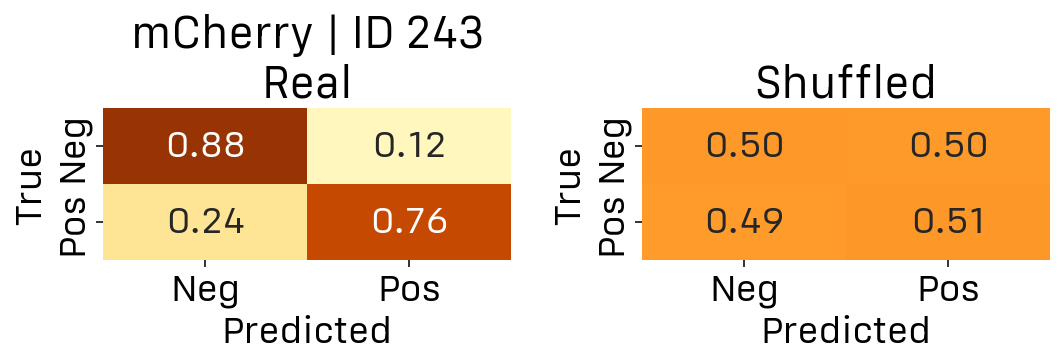

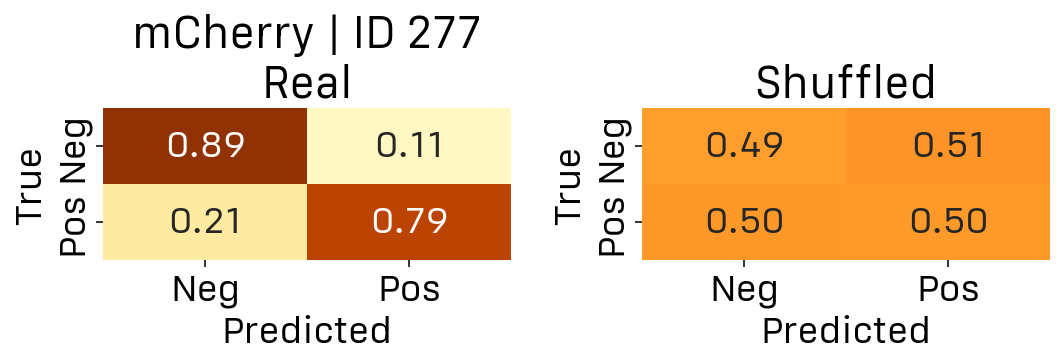

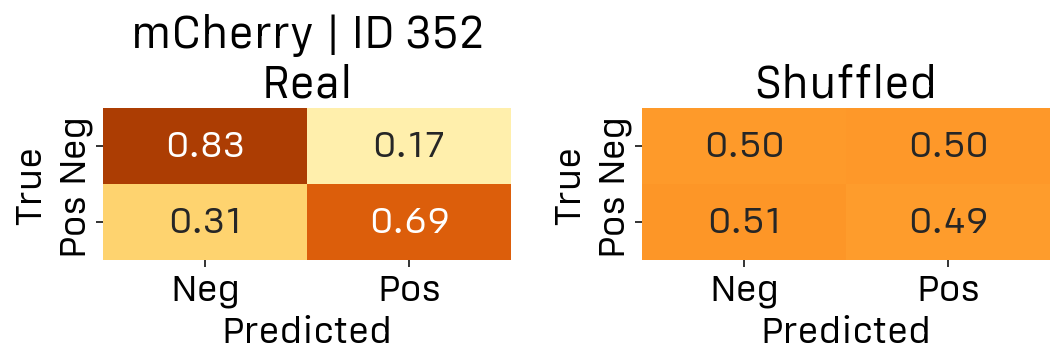

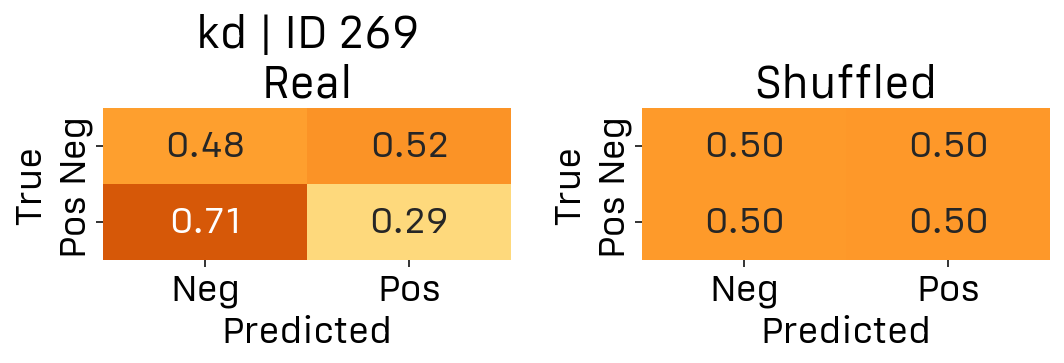

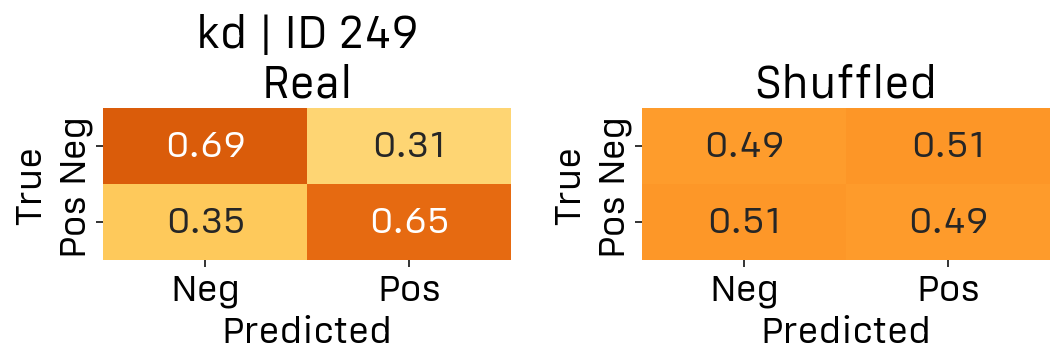

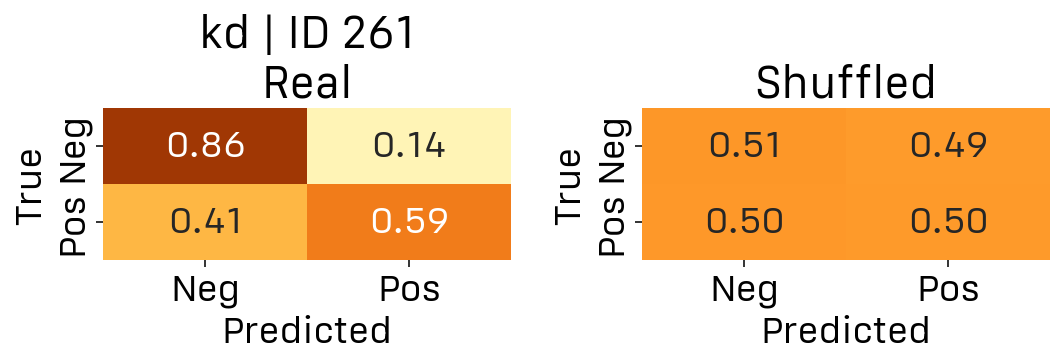

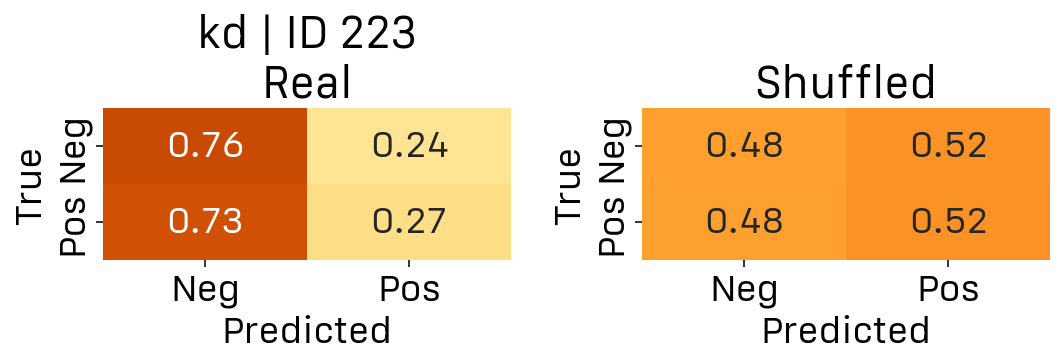

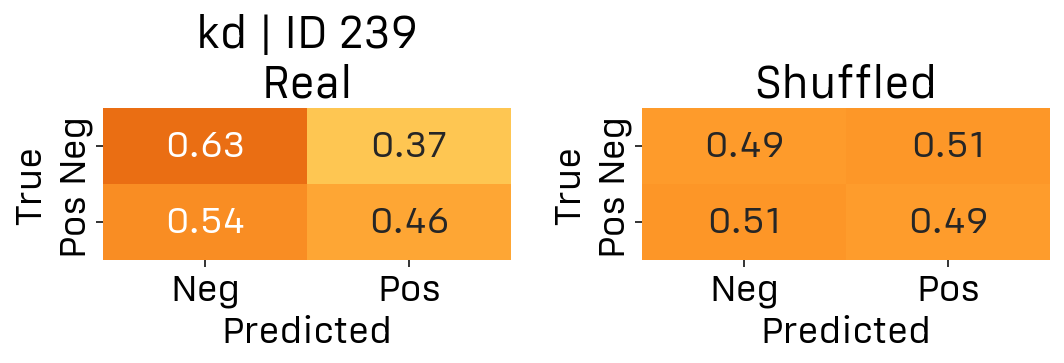

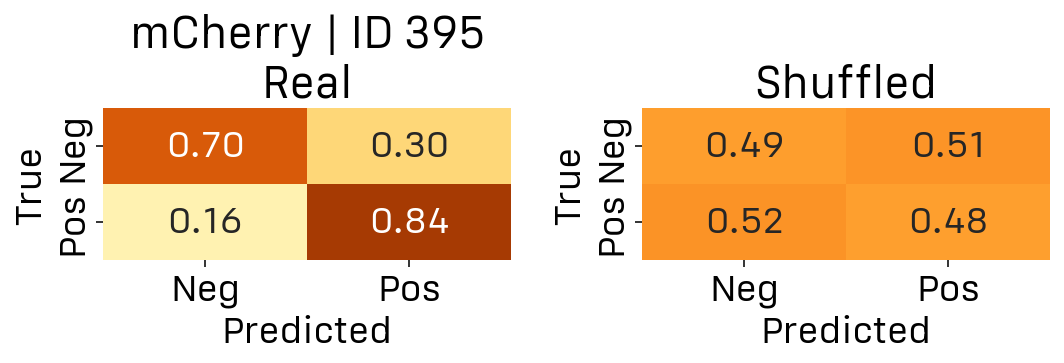

In [12]:
for (cond, mouse_id), cm in avg_cm_mouse.items():

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))

    sns.heatmap(
        cm,
        annot=True, fmt=".2f", cmap="YlOrBr",
        vmin=0, vmax=1, cbar=False,
        xticklabels=['Neg', 'Pos'],
        yticklabels=['Neg', 'Pos'],
        ax=axes[0]
    )
    axes[0].set_title(f"{cond} | ID {mouse_id}\nReal")

    sns.heatmap(
        avg_shuff_cm_mouse[(cond, mouse_id)],
        annot=True, fmt=".2f", cmap="YlOrBr",
        vmin=0, vmax=1, cbar=False,
        xticklabels=['Neg', 'Pos'],
        yticklabels=['Neg', 'Pos'],
        ax=axes[1]
    )
    axes[1].set_title("Shuffled")
    for ax in axes:
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    plt.tight_layout()
    plt.show()


#### group confusion matrices

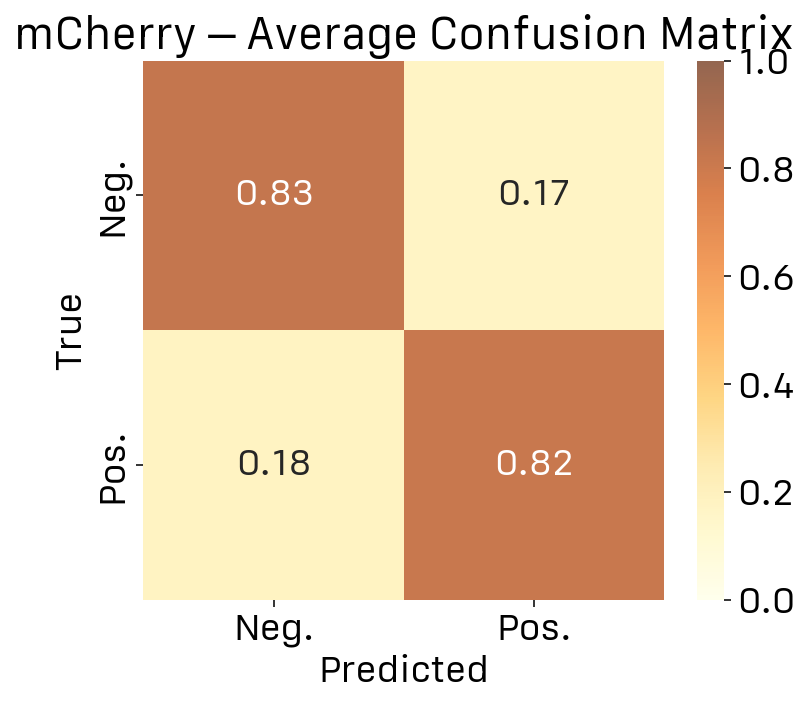

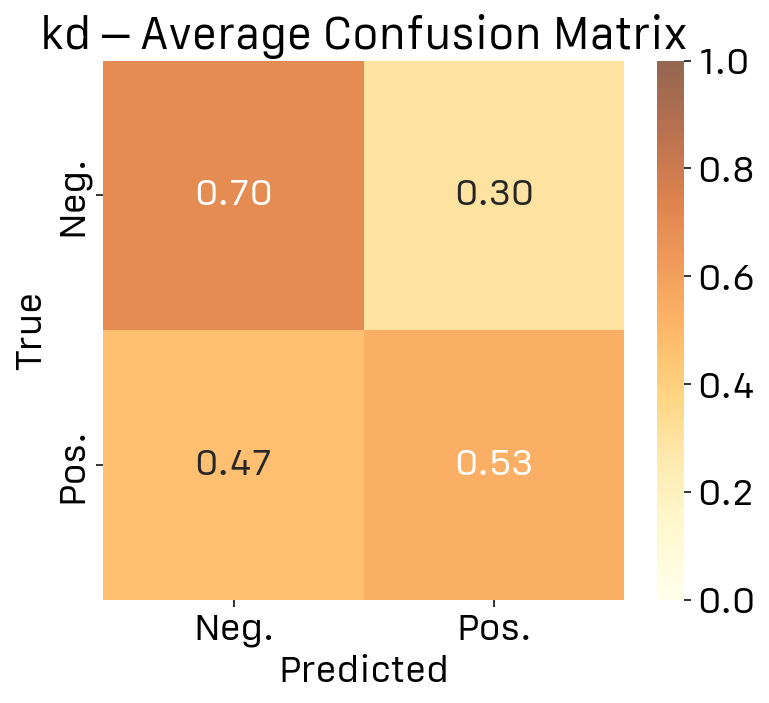

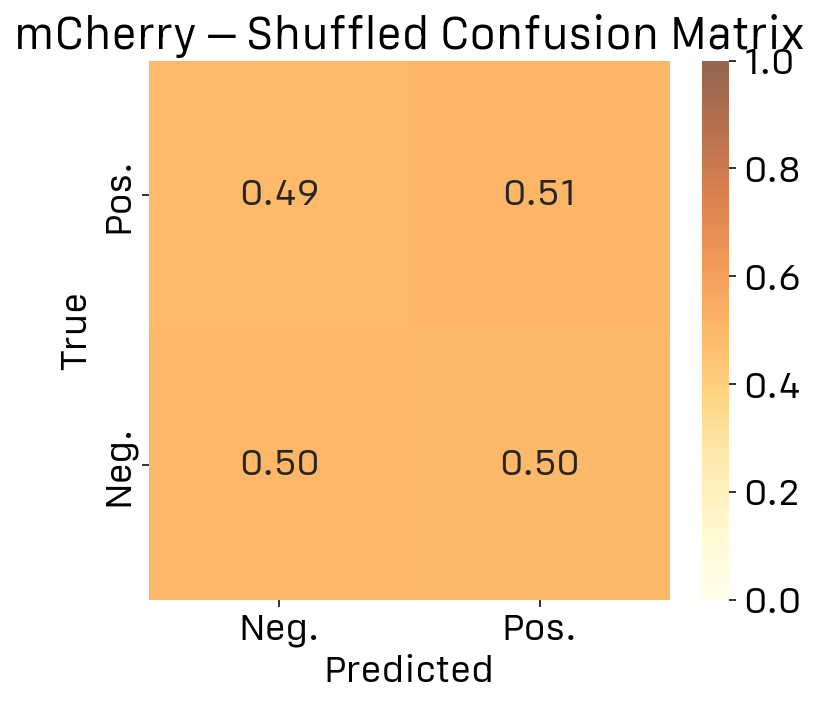

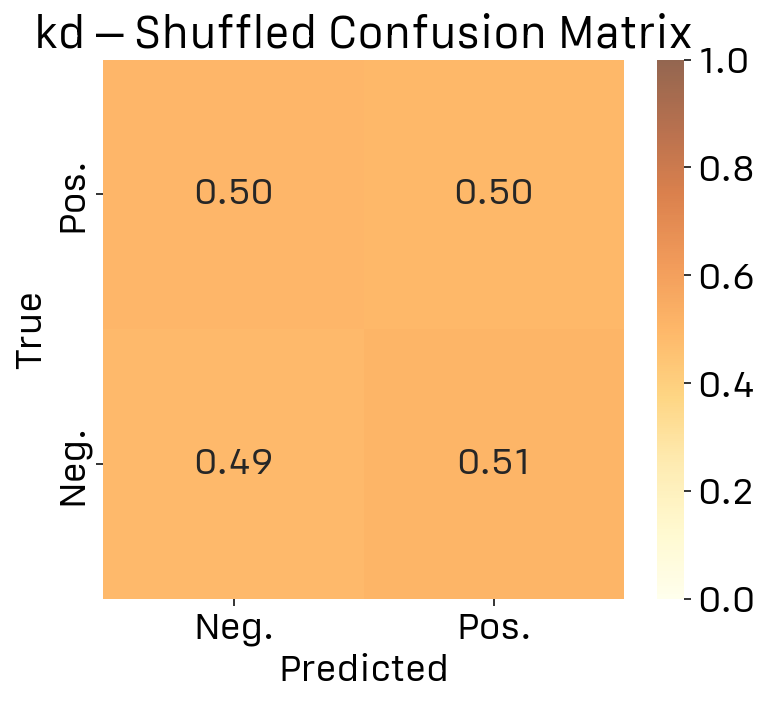

In [10]:
## confusion matrices 
for cond, cm in final_cm.items():
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt=".2f", cmap="YlOrBr", alpha = 0.7,
        vmin=0, vmax=1,
        xticklabels=['Neg.', 'Pos.'],
        yticklabels=['Neg.', 'Pos.']
    )
    plt.title(f"{cond} – Average Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    # plt.savefig(f'/Users/ossamaghenissa/Desktop/CMRlabproject/fiberphotometry/MG/decoder/figures/{cond}_SAMtoEPM_confusionmatrix.pdf', format='pdf')
    plt.show()

for cond, cm in final_shuff_cm.items():
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt=".2f", cmap="YlOrBr", alpha = 0.7,
        vmin=0, vmax=1,
        xticklabels=['Neg.', 'Pos.'],
        yticklabels=['Pos.', 'Neg.']
    )
    plt.title(f"{cond} – Shuffled Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


#### accuracy

     ID condition  Accuracy  Precision    Recall        F1      1_f1  \
0   223        kd  0.545751   0.527172  0.545751  0.503773  0.313519   
1   224        kd  0.828406   0.856683  0.828406  0.835243  0.724766   
2   238        kd  0.731479   0.822681  0.731479  0.754069  0.559888   
3   239        kd  0.560127   0.558873  0.560127  0.559161  0.462000   
4   243   mCherry  0.853016   0.867954  0.853016  0.857467  0.697052   
5   249        kd  0.672747   0.675413  0.672747  0.673677  0.629125   
6   261        kd  0.783375   0.780482  0.783375  0.781642  0.604303   
7   268        kd  0.467254   0.525214  0.467254  0.464340  0.455785   
8   269        kd  0.411544   0.428915  0.411544  0.418564  0.268879   
9   273   mCherry  0.841899   0.902804  0.841899  0.857213  0.657977   
10  277   mCherry  0.857551   0.857360  0.857551  0.857396  0.795395   
11  352   mCherry  0.808183   0.872134  0.808183  0.830177  0.489193   
12  363   mCherry  0.748816   0.962036  0.748816  0.828752  0.18

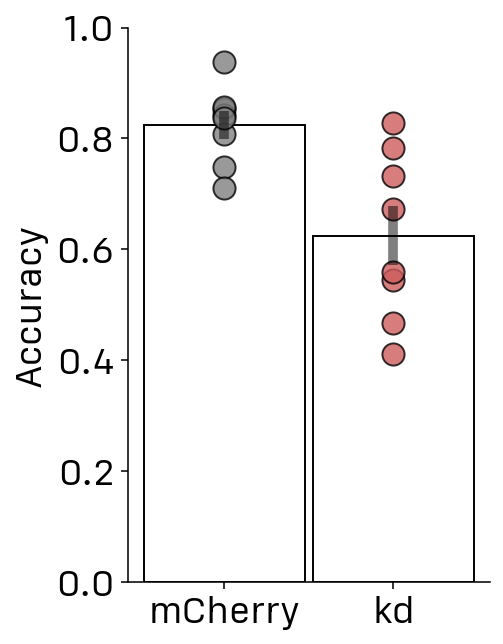

In [7]:
def barplot_anything(df, var):
    df = average_results.copy()
    df.to_csv('/Users/ossamaghenissa/Desktop/CMRlabproject/fiberphotometry/raw_data/8q.csv', index=False)
    print(df)

    plt.figure(figsize=(4,5))

    conditions = ['mCherry', 'kd']

    means = df.groupby('condition')[var].mean().loc[conditions]
    print(means)
    sems  = df.groupby('condition')[var].sem().loc[conditions]
    print(sems)

    # stats (unpaired)
    from scipy.stats import ttest_ind
    ttest_results = ttest_ind(
        df[df['condition'] == 'kd'][var],
        df[df['condition'] == 'mCherry'][var]
    )

    print(ttest_results)

    # bar plot
    plt.bar(
        conditions,
        means,
        yerr=sems,
        color='none',
        edgecolor='black',
        capsize=0,
        width=0.95,
        error_kw=dict(lw=5, alpha=0.5, zorder=4),
        zorder=0
    )

    # scatter (one dot per mouse)
    colors = {'kd': 'indianred', 'mCherry': 'grey'}

    for cond in conditions:
        y = df[df['condition'] == cond][var]
        x = [cond] * len(y)
        plt.scatter(
            x, y,
            color=colors[cond],
            edgecolor='black',
            s=130,
            zorder=3, 
            alpha=0.8
        )

    plt.ylabel(var)
    ax = plt.gca()
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    plt.ylim(0, 1)
    plt.yticks([0, .2, .4, .6, .8, 1])
    plt.tight_layout()
    # plt.savefig(f'/Users/ossamaghenissa/Desktop/CMRlabproject/fiberphotometry/MG/decoder/figures/SAMtoEPM_decoder_{var}_KDvsMcherry.pdf', format='pdf')
    plt.show()

barplot_anything(average_results, 'Accuracy')


     ID condition  Accuracy  Precision    Recall        F1      1_f1  \
0   223        kd  0.545751   0.527172  0.545751  0.503773  0.313519   
1   224        kd  0.828406   0.856683  0.828406  0.835243  0.724766   
2   238        kd  0.731479   0.822681  0.731479  0.754069  0.559888   
3   239        kd  0.560127   0.558873  0.560127  0.559161  0.462000   
4   243   mCherry  0.853016   0.867954  0.853016  0.857467  0.697052   
5   249        kd  0.672747   0.675413  0.672747  0.673677  0.629125   
6   261        kd  0.783375   0.780482  0.783375  0.781642  0.604303   
7   268        kd  0.467254   0.525214  0.467254  0.464340  0.455785   
8   269        kd  0.411544   0.428915  0.411544  0.418564  0.268879   
9   273   mCherry  0.841899   0.902804  0.841899  0.857213  0.657977   
10  277   mCherry  0.857551   0.857360  0.857551  0.857396  0.795395   
11  352   mCherry  0.808183   0.872134  0.808183  0.830177  0.489193   
12  363   mCherry  0.748816   0.962036  0.748816  0.828752  0.18

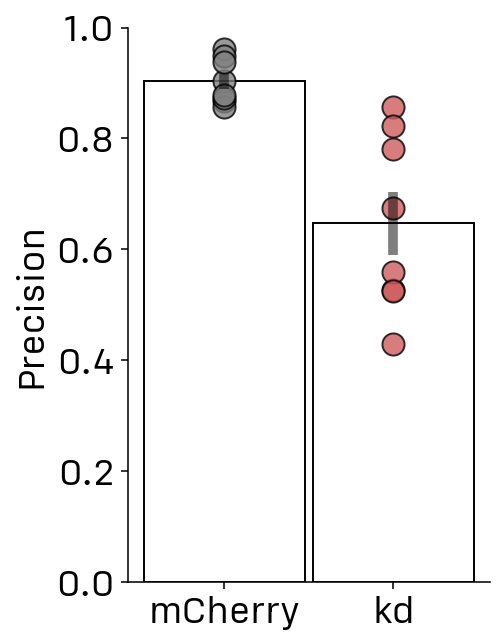

In [ ]:
def barplot_anything(df, var):
    df = average_results.copy()
    print(df)

    plt.figure(figsize=(4,5))

    conditions = ['mCherry', 'kd']

    means = df.groupby('condition')[var].mean().loc[conditions]
    print(means)
    sems  = df.groupby('condition')[var].sem().loc[conditions]
    print(sems)

    ttest_results = ttest_ind(
        df[df['condition'] == 'kd'][var],
        df[df['condition'] == 'mCherry'][var]
    )

    print(ttest_results)

    # bar plot
    plt.bar(
        conditions,
        means,
        yerr=sems,
        color='none',
        edgecolor='black',
        capsize=0,
        width=0.95,
        error_kw=dict(lw=5, alpha=0.5, zorder=4),
        zorder=0
    )

    # scatter (one dot per mouse)
    colors = {'kd': 'indianred', 'mCherry': 'grey'}

    for cond in conditions:
        y = df[df['condition'] == cond][var]
        x = [cond] * len(y)
        plt.scatter(
            x, y,
            color=colors[cond],
            edgecolor='black',
            s=130,
            zorder=3, 
            alpha=0.8
        )

    plt.ylabel(var)
    ax = plt.gca()
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    plt.ylim(0, 1)
    plt.yticks([0, .2, .4, .6, .8, 1])
    plt.tight_layout()
    # plt.savefig(f'/Users/ossamaghenissa/Desktop/CMRlabproject/fiberphotometry/MG/decoder/figures/SAMtoEPM_decoder_{var}_KDvsMcherry.pdf', format='pdf')
    plt.show()

barplot_anything(average_results, 'Precision')

     ID condition  Accuracy  Precision    Recall        F1      1_f1  \
0   223        kd  0.545751   0.527172  0.545751  0.503773  0.313519   
1   224        kd  0.828406   0.856683  0.828406  0.835243  0.724766   
2   238        kd  0.731479   0.822681  0.731479  0.754069  0.559888   
3   239        kd  0.560127   0.558873  0.560127  0.559161  0.462000   
4   243   mCherry  0.853016   0.867954  0.853016  0.857467  0.697052   
5   249        kd  0.672747   0.675413  0.672747  0.673677  0.629125   
6   261        kd  0.783375   0.780482  0.783375  0.781642  0.604303   
7   268        kd  0.467254   0.525214  0.467254  0.464340  0.455785   
8   269        kd  0.411544   0.428915  0.411544  0.418564  0.268879   
9   273   mCherry  0.841899   0.902804  0.841899  0.857213  0.657977   
10  277   mCherry  0.857551   0.857360  0.857551  0.857396  0.795395   
11  352   mCherry  0.808183   0.872134  0.808183  0.830177  0.489193   
12  363   mCherry  0.748816   0.962036  0.748816  0.828752  0.18

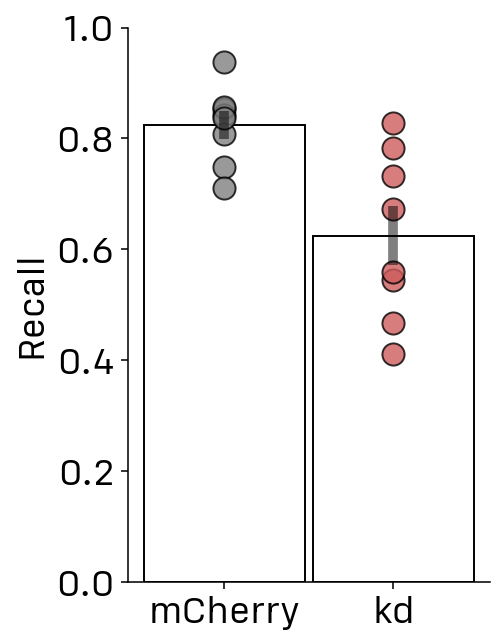

In [17]:
def barplot_anything(df, var):
    df = average_results.copy()
    print(df)

    plt.figure(figsize=(4,5))

    conditions = ['mCherry', 'kd']

    means = df.groupby('condition')[var].mean().loc[conditions]
    print(means)
    sems  = df.groupby('condition')[var].sem().loc[conditions]
    print(sems)

    # stats (unpaired)
    from scipy.stats import ttest_ind
    ttest_results = ttest_ind(
        df[df['condition'] == 'kd'][var],
        df[df['condition'] == 'mCherry'][var]
    )

    print(ttest_results)

    # bar plot
    plt.bar(
        conditions,
        means,
        yerr=sems,
        color='none',
        edgecolor='black',
        capsize=0,
        width=0.95,
        error_kw=dict(lw=5, alpha=0.5, zorder=4),
        zorder=0
    )

    # scatter (one dot per mouse)
    colors = {'kd': 'indianred', 'mCherry': 'grey'}

    for cond in conditions:
        y = df[df['condition'] == cond][var]
        x = [cond] * len(y)
        plt.scatter(
            x, y,
            color=colors[cond],
            edgecolor='black',
            s=130,
            zorder=3, 
            alpha=0.8
        )

    plt.ylabel(var)
    ax = plt.gca()
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    plt.ylim(0, 1)
    plt.yticks([0, .2, .4, .6, .8, 1])
    plt.tight_layout()
    # plt.savefig(f'/Users/ossamaghenissa/Desktop/CMRlabproject/fiberphotometry/MG/decoder/figures/SAMtoEPM_decoder_{var}_KDvsMcherry.pdf', format='pdf')
    plt.show()

barplot_anything(average_results, 'Recall')

     ID condition  Accuracy  Precision    Recall        F1      1_f1  \
0   223        kd  0.545751   0.527172  0.545751  0.503773  0.313519   
1   224        kd  0.828406   0.856683  0.828406  0.835243  0.724766   
2   238        kd  0.731479   0.822681  0.731479  0.754069  0.559888   
3   239        kd  0.560127   0.558873  0.560127  0.559161  0.462000   
4   243   mCherry  0.853016   0.867954  0.853016  0.857467  0.697052   
5   249        kd  0.672747   0.675413  0.672747  0.673677  0.629125   
6   261        kd  0.783375   0.780482  0.783375  0.781642  0.604303   
7   268        kd  0.467254   0.525214  0.467254  0.464340  0.455785   
8   269        kd  0.411544   0.428915  0.411544  0.418564  0.268879   
9   273   mCherry  0.841899   0.902804  0.841899  0.857213  0.657977   
10  277   mCherry  0.857551   0.857360  0.857551  0.857396  0.795395   
11  352   mCherry  0.808183   0.872134  0.808183  0.830177  0.489193   
12  363   mCherry  0.748816   0.962036  0.748816  0.828752  0.18

/var/folders/f5/1b9s96g507d8lm318wd11vrc0000gp/T/ipykernel_49829/3242687381.py:56: UserWarning: Glyph 95 (_) missing from font(s) .SF Camera.
  plt.tight_layout()
/Users/ossamaghenissa/fpenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 95 (_) missing from font(s) .SF Camera.
  fig.canvas.print_figure(bytes_io, **kw)


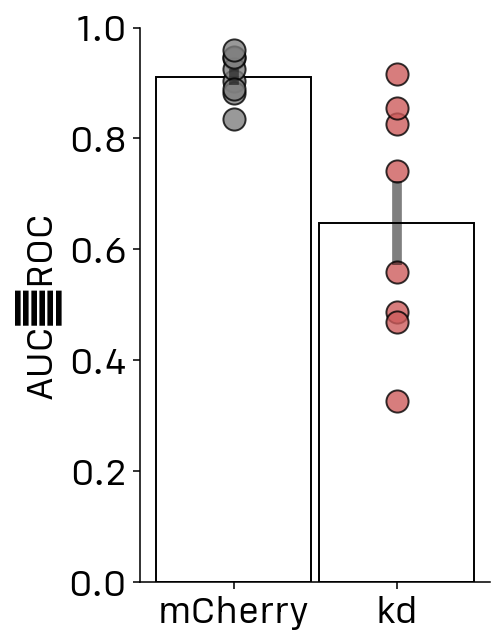

In [18]:
def barplot_anything(df, var):
    df = average_results.copy()
    print(df)

    plt.figure(figsize=(4,5))

    conditions = ['mCherry', 'kd']

    means = df.groupby('condition')[var].mean().loc[conditions]
    print(means)
    sems  = df.groupby('condition')[var].sem().loc[conditions]
    print(sems)

    # stats (unpaired)
    from scipy.stats import ttest_ind
    ttest_results = ttest_ind(
        df[df['condition'] == 'kd'][var],
        df[df['condition'] == 'mCherry'][var]
    )

    print(ttest_results)

    # bar plot
    plt.bar(
        conditions,
        means,
        yerr=sems,
        color='none',
        edgecolor='black',
        capsize=0,
        width=0.95,
        error_kw=dict(lw=5, alpha=0.5, zorder=4),
        zorder=0
    )

    # scatter (one dot per mouse)
    colors = {'kd': 'indianred', 'mCherry': 'grey'}

    for cond in conditions:
        y = df[df['condition'] == cond][var]
        x = [cond] * len(y)
        plt.scatter(
            x, y,
            color=colors[cond],
            edgecolor='black',
            s=130,
            zorder=3, 
            alpha=0.8
        )

    plt.ylabel(var)
    ax = plt.gca()
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    plt.ylim(0, 1)
    plt.yticks([0, .2, .4, .6, .8, 1])
    plt.tight_layout()
    # plt.savefig(f'/Users/ossamaghenissa/Desktop/CMRlabproject/fiberphotometry/MG/decoder/figures/SAMtoEPM_decoder_{var}_KDvsMcherry.pdf', format='pdf')
    plt.show()

barplot_anything(average_results, 'AUC_ROC')